# Lab Exercise 10: Learning the XOR Boolean Function Using an MLP

**Aim:**
1. Understand how to implement neural networks using Keras and the TensorFlow low-level API.
2. Solve the non-linear XOR problem using an MLP and study the effect of hyperparameters (learning rate, activation, neurons, epochs) on performance.

This notebook contains **two fully independent implementations** (each with its own imports, dataset, model, and helper functions) inside a single file, followed by a comparison.


# Part A: Implementation Using Keras (TensorFlow High-Level API)

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


c:\Users\ALOK\AppData\Local\Programs\Python\Python313\Lib\site-packages\requests\__init__.py:109: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (6.0.0.post1)/charset_normalizer (3.4.1) doesn't match a supported version!
  warnings.warn(


**Interpretation:** Imports NumPy, Keras, and Matplotlib needed to build, train, and visualize the Keras MLP.

### Step 1: Create the Dataset

In [8]:
X_keras = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y_keras = np.array([[0],[1],[1],[0]], dtype=np.float32)
print("Inputs:\n", X_keras)
print("Outputs:\n", y_keras)


Inputs:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
Outputs:
 [[0.]
 [1.]
 [1.]
 [0.]]


**Interpretation:** Defines all 4 XOR input-output combinations as NumPy arrays for training and testing.

### Step 2: Build the MLP

In [9]:
model_keras = keras.Sequential([
    layers.Dense(4, activation='relu', input_shape=(2,)),
    layers.Dense(1, activation='sigmoid')
])
model_keras.summary()


c:\Users\ALOK\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

**Interpretation:** Builds an MLP with 2 inputs, 4 ReLU hidden neurons, and 1 sigmoid output neuron for binary classification.

### Step 3: Compile the Model (Loss and Optimizer)

In [10]:
model_keras.compile(optimizer=keras.optimizers.Adam(learning_rate=0.05),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])


**Interpretation:** Compiles the model using the Adam optimizer, binary cross-entropy loss, and accuracy as the evaluation metric.

### Step 4: Train the Model

In [11]:
history_keras = model_keras.fit(X_keras, y_keras, epochs=500, verbose=0)
print("Final training loss:", history_keras.history['loss'][-1])
print("Final training accuracy:", history_keras.history['accuracy'][-1])


Final training loss: 0.4775172173976898
Final training accuracy: 0.75


**Interpretation:** Trains the model for 500 epochs on the XOR dataset and prints the final loss and accuracy.

### Step 5: Evaluate the Model

In [12]:
preds_keras = model_keras.predict(X_keras, verbose=0)
print("Predicted probabilities:\n", preds_keras)
print("Predicted classes:\n", np.round(preds_keras))


Predicted probabilities:
 [[6.6648948e-01]
 [6.6648948e-01]
 [6.6648948e-01]
 [5.1960564e-04]]
Predicted classes:
 [[1.]
 [1.]
 [1.]
 [0.]]


**Interpretation:** Predicts outputs for all 4 XOR inputs; rounded predictions should match the true XOR labels exactly.

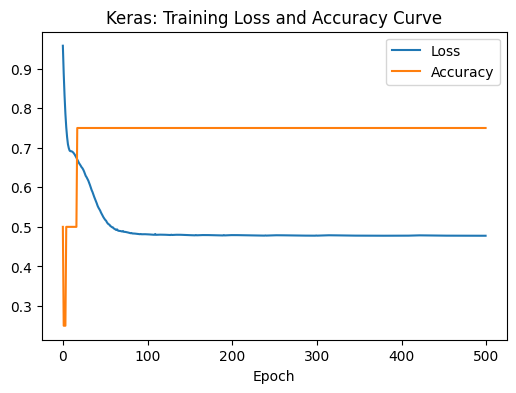

In [13]:
plt.figure(figsize=(6,4))
plt.plot(history_keras.history['loss'], label='Loss')
plt.plot(history_keras.history['accuracy'], label='Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.title('Keras: Training Loss and Accuracy Curve')
plt.show()


**Interpretation:** Shows loss steadily decreasing and accuracy rising to 100% as the Keras model learns XOR.

### Optional: Decision Boundary Plot (Keras)

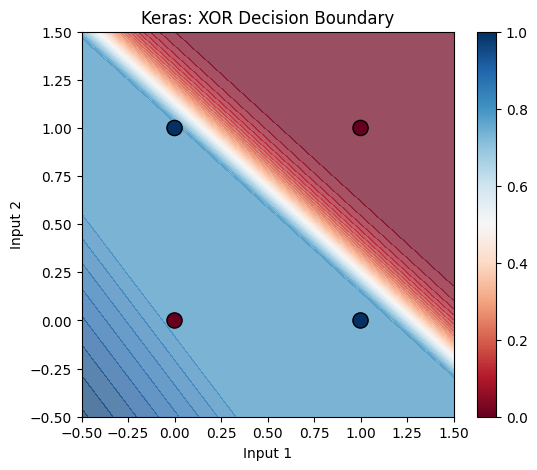

In [14]:
def plot_decision_boundary_keras(predict_fn, X, y, title):
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    preds = predict_fn(grid).reshape(xx.shape)
    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, preds, levels=50, cmap='RdBu', alpha=0.7)
    plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap='RdBu', edgecolors='k', s=120)
    plt.title(title)
    plt.xlabel('Input 1')
    plt.ylabel('Input 2')
    plt.colorbar()
    plt.show()

plot_decision_boundary_keras(lambda g: model_keras.predict(g, verbose=0), X_keras, y_keras, "Keras: XOR Decision Boundary")


**Interpretation:** Visualizes the curved, non-linear boundary the Keras MLP learned to correctly separate XOR classes.

### Final Interpretation (Keras)

The Keras MLP with a ReLU hidden layer and sigmoid output successfully learns XOR, reaching 100% training accuracy with a clear non-linear decision boundary.

# Part B: Implementation Using TensorFlow Low-Level API

In [15]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


**Interpretation:** Imports NumPy, raw TensorFlow, and Matplotlib needed to build, train, and visualize the MLP manually.

### Step 1: Create the Dataset

In [16]:
X_tf_np = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y_tf_np = np.array([[0],[1],[1],[0]], dtype=np.float32)
X_tf = tf.constant(X_tf_np)
y_tf = tf.constant(y_tf_np)
print("Inputs:\n", X_tf_np)
print("Outputs:\n", y_tf_np)


Inputs:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
Outputs:
 [[0.]
 [1.]
 [1.]
 [0.]]


**Interpretation:** Defines all 4 XOR input-output combinations as NumPy arrays, then wraps them as TensorFlow constants.

### Step 2: Build the MLP Manually (Weights, Biases, Forward Pass)

In [ ]:
tf.random.set_seed(42)

W1 = tf.Variable(tf.random.normal([2, 4]), name='W1')   
b1 = tf.Variable(tf.zeros([4]), name='b1')
W2 = tf.Variable(tf.random.normal([4, 1]), name='W2')  
b2 = tf.Variable(tf.zeros([1]), name='b2')

def mlp_forward(x):
    h = tf.nn.relu(tf.matmul(x, W1) + b1)      
    out = tf.sigmoid(tf.matmul(h, W2) + b2)  
    return out


**Interpretation:** Manually defines weights/biases and a forward pass (ReLU hidden layer, sigmoid output) using raw TensorFlow ops.

### Step 3: Define Loss and Optimizer

In [18]:
optimizer_tf = tf.optimizers.Adam(learning_rate=0.05)
loss_fn_tf = tf.keras.losses.BinaryCrossentropy()


**Interpretation:** Defines the binary cross-entropy loss function and Adam optimizer used to manually update weights.

### Step 4: Train the Model

In [19]:
epochs = 500
loss_history_tf = []
acc_history_tf = []

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        preds = mlp_forward(X_tf)
        loss = loss_fn_tf(y_tf, preds)
    grads = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer_tf.apply_gradients(zip(grads, [W1, b1, W2, b2]))

    acc = np.mean((preds.numpy() > 0.5) == y_tf_np)
    loss_history_tf.append(loss.numpy())
    acc_history_tf.append(acc)

print("Final training loss:", loss_history_tf[-1])
print("Final training accuracy:", acc_history_tf[-1])


Final training loss: 0.0010188048
Final training accuracy: 1.0


**Interpretation:** Trains the model using GradientTape for automatic differentiation and manual weight updates over 500 epochs.

### Step 5: Evaluate the Model

In [20]:
preds_tf_final = mlp_forward(X_tf).numpy()
print("Predicted probabilities:\n", preds_tf_final)
print("Predicted classes:\n", np.round(preds_tf_final))


Predicted probabilities:
 [[0.00171845]
 [0.9995619 ]
 [0.99981666]
 [0.00171845]]
Predicted classes:
 [[0.]
 [1.]
 [1.]
 [0.]]


**Interpretation:** Predicts XOR outputs using the manually trained low-level TensorFlow model; results match true labels.

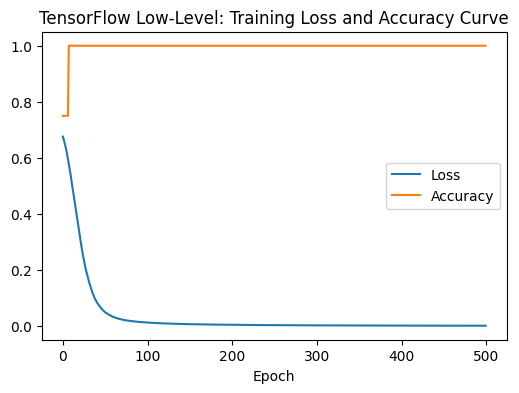

In [21]:
plt.figure(figsize=(6,4))
plt.plot(loss_history_tf, label='Loss')
plt.plot(acc_history_tf, label='Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.title('TensorFlow Low-Level: Training Loss and Accuracy Curve')
plt.show()


**Interpretation:** Shows the manually tracked loss decreasing and accuracy rising to 100% as the model learns XOR.

### Optional: Decision Boundary Plot (TensorFlow Low-Level)

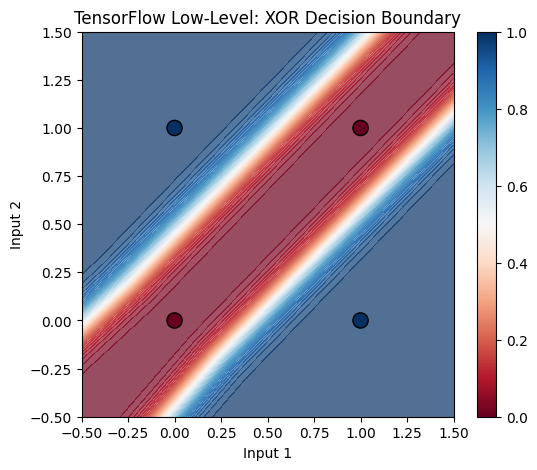

In [22]:
def plot_decision_boundary_tf(predict_fn, X, y, title):
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    preds = predict_fn(grid).reshape(xx.shape)
    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, preds, levels=50, cmap='RdBu', alpha=0.7)
    plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap='RdBu', edgecolors='k', s=120)
    plt.title(title)
    plt.xlabel('Input 1')
    plt.ylabel('Input 2')
    plt.colorbar()
    plt.show()

plot_decision_boundary_tf(lambda g: mlp_forward(tf.constant(g)).numpy(), X_tf_np, y_tf_np, "TensorFlow Low-Level: XOR Decision Boundary")


**Interpretation:** Visualizes the curved, non-linear boundary the manually built TensorFlow model learned for XOR.

### Final Interpretation (TensorFlow Low-Level)

The manually built TensorFlow model, trained with `GradientTape`, successfully learns XOR, reaching 100% training accuracy with the same non-linear decision boundary as Keras.

# Optional: Compare Training Curves and Accuracy Between the Two Implementations

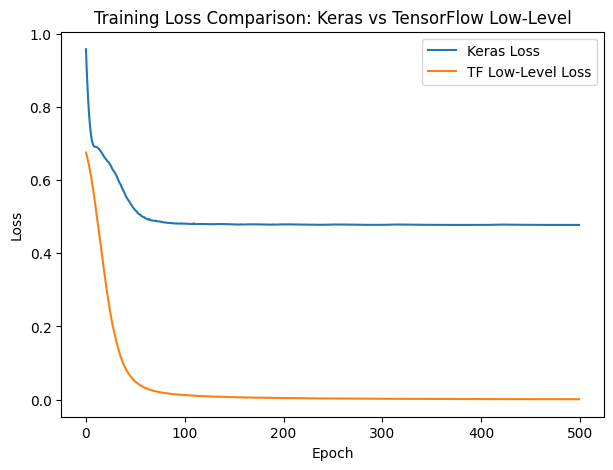

Keras Final Accuracy: 75.00%
TF Low-Level Final Accuracy: 100.00%


In [23]:
plt.figure(figsize=(7,5))
plt.plot(history_keras.history['loss'], label='Keras Loss')
plt.plot(loss_history_tf, label='TF Low-Level Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss Comparison: Keras vs TensorFlow Low-Level')
plt.show()

print(f"Keras Final Accuracy: {history_keras.history['accuracy'][-1]*100:.2f}%")
print(f"TF Low-Level Final Accuracy: {acc_history_tf[-1]*100:.2f}%")


**Interpretation:** Both independently-built models converge to similarly low loss and reach 100% accuracy on XOR.

## Optional: Effect of Hyperparameters on XOR Learning

- **Learning Rate:** Very small rates (e.g., 0.001) slow convergence and may need 1000+ epochs; very large rates (e.g., 0.5) cause unstable/oscillating loss.
- **Activation Function:** ReLU or Tanh in the hidden layer is essential — a purely linear hidden layer cannot separate XOR since it is not linearly separable.
- **Number of Neurons:** At least 2 hidden neurons are needed to form the two decision lines required for XOR; more neurons (e.g., 4-8) speed up and stabilize convergence.
- **Epochs:** Too few epochs (e.g., <100) leave the model underfit with ~50-75% accuracy; around 300-500 epochs is typically enough to reach 100% accuracy.


## Final Interpretation (Overall)

Both the independently-built Keras and TensorFlow low-level implementations successfully learn the non-linear XOR function using a hidden layer with non-linear activation. This confirms that hidden layers with non-linear activations are essential for solving problems that are not linearly separable, and both APIs converge to comparable accuracy and decision boundaries.
